## <b>Gold price prediction using ML</b>

### Data collection
conclusion:
dataset contains 2290 rows and 6 columns
dataset dont have null values

In [1]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn import metrics

In [2]:
#Load Dataset
df1=pd.read_csv("gold_model_dataset_2008_2018.csv")
df2=pd.read_csv("gold_model_dataset_2015_2025.csv")

EDA

In [3]:
#Shape of dataset
df1.shape

(2290, 6)

In [4]:
df2.shape

(2527, 6)

In [5]:
df2.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,NaN,NaN,NaN,NaN,NaN,NaN
1,2015-06-01,2111.729980,114.000000,162.880005,16.00,1.095794
2,2015-06-02,2109.600098,114.459999,165.440002,16.07,1.092299
3,2015-06-03,2114.070068,113.639999,161.360001,15.83,1.115001
4,2015-06-04,2095.840088,112.839996,157.279999,15.48,1.125784


In [6]:
#Head of dataset
df1.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


In [7]:
#Tail of dataset
df1.tail(5)

,Date,SPX,GLD,USO,SLV,EUR/USD
2285,5/8/2018,2671.919922,124.589996,14.0600,15.5100,1.186789
2286,5/9/2018,2697.790039,124.330002,14.3700,15.5300,1.184722
2287,5/10/2018,2723.070068,125.180000,14.4100,15.7400,1.191753
2288,5/14/2018,2730.129883,124.489998,14.3800,15.5600,1.193118
2289,5/16/2018,2725.780029,122.543800,14.4058,15.4542,1.182033


In [8]:
df1['Date']=pd.to_datetime(df1.Date)
df2['Date']=pd.to_datetime(df2.Date,errors='coerce') 

In [9]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2290 entries, 0 to 2289
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2290 non-null   datetime64[ns]
 1   SPX      2290 non-null   float64       
 2   GLD      2290 non-null   float64       
 3   USO      2290 non-null   float64       
 4   SLV      2290 non-null   float64       
 5   EUR/USD  2290 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 107.5 KB


In [10]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2527 entries, 0 to 2526
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     2526 non-null   datetime64[ns]
 1   SPX      2526 non-null   float64       
 2   GLD      2526 non-null   float64       
 3   USO      2526 non-null   float64       
 4   SLV      2526 non-null   float64       
 5   EUR/USD  2526 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 118.6 KB


In [11]:
datasets = [
    (df1, 'df1 (2008-2018)'),
    (df2, 'df2 (2015-2025)')
]
print("SUMMARY STATISTICS")
print("="*60)
for df, title in datasets:
    print(f"\n{title}:")
    print(f"  Mean:   ${df['USO'].mean():.2f}")
    print(f"  Median: ${df['USO'].median():.2f}")
    print(f"  Std:    ${df['USO'].std():.2f}")
    print(f"  Min:    ${df['USO'].min():.2f}")
    print(f"  Max:    ${df['USO'].max():.2f}")
    print(f"  Range:  ${df['USO'].max() - df['USO'].min():.2f}")

SUMMARY STATISTICS

df1 (2008-2018):
  Mean:   $31.84
  Median: $33.87
  Std:    $19.52
  Min:    $7.96
  Max:    $117.48
  Range:  $109.52

df2 (2015-2025):
  Mean:   $77.60
  Median: $77.76
  Std:    $24.56
  Min:    $17.04
  Max:    $165.44
  Range:  $148.40


In [12]:
df1.describe()

,Date,SPX,GLD,USO,SLV,EUR/USD
count,2290,2290.000000,2290.000000,2290.000000,2290.000000,2290.000000
mean,2013-03-17 08:23:41.135371008,1654.315776,122.732875,31.842221,20.084997,1.283653
min,2008-01-02 00:00:00,676.530029,70.000000,7.960000,8.850000,1.039047
25%,2010-08-20 00:00:00,1239.874969,109.725000,14.380000,15.570000,1.171313
50%,2013-03-13 12:00:00,1551.434998,120.580002,33.869999,17.268500,1.303297
75%,2015-10-25 00:00:00,2073.010070,132.840004,37.827501,22.882500,1.369971
max,2018-05-16 00:00:00,2872.870117,184.589996,117.480003,47.259998,1.598798
std,NaN,519.111540,23.283346,19.523517,7.092566,0.131547


In [13]:
df2.describe()

,Date,SPX,GLD,USO,SLV,EUR/USD
count,2526,2526.000000,2526.000000,2526.000000,2526.000000,2526.000000
mean,2020-06-07 08:05:42.042755328,3519.880051,158.064778,77.604549,19.333535,1.117931
min,2015-06-01 00:00:00,1829.079956,100.500000,17.040001,11.210000,0.959619
25%,2017-12-01 18:00:00,2562.730103,121.282499,67.139999,15.500000,1.083550
50%,2020-06-09 12:00:00,3241.824951,158.484993,77.755001,17.685000,1.114318
75%,2022-12-08 18:00:00,4369.669922,178.455002,91.740002,22.530001,1.155064
max,2025-06-20 00:00:00,6144.149902,316.290009,165.440002,33.740002,1.251001
std,NaN,1162.821209,44.113391,24.561073,4.726707,0.052820


In [14]:
#check missing values
df1.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [15]:
df1=df1.dropna()
df2=df2.dropna()

In [16]:
df1['USO']=df1.USO*8

In [17]:
df1.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD
0,2008-01-02,1447.160034,84.860001,627.760008,15.180,1.471692
1,2008-01-03,1447.160034,85.570000,626.960024,15.285,1.474491
2,2008-01-04,1411.630005,85.129997,618.479984,15.167,1.475492
3,2008-01-07,1416.180054,84.769997,604.000000,15.053,1.468299
4,2008-01-08,1390.189941,86.779999,608.479984,15.590,1.557099


In [18]:
df2.head(5)

,Date,SPX,GLD,USO,SLV,EUR/USD
1,2015-06-01,2111.729980,114.000000,162.880005,16.00,1.095794
2,2015-06-02,2109.600098,114.459999,165.440002,16.07,1.092299
3,2015-06-03,2114.070068,113.639999,161.360001,15.83,1.115001
4,2015-06-04,2095.840088,112.839996,157.279999,15.48,1.125784
5,2015-06-05,2092.830078,112.239998,159.199997,15.39,1.120787


C:\Users\tanma\AppData\Local\Temp\ipykernel_33240\791151678.py:14: MatplotlibDeprecationWarning: Passing label as a length 2290 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df1['Date'],df1.USO, label=df1.USO)
C:\Users\tanma\AppData\Local\Temp\ipykernel_33240\791151678.py:18: MatplotlibDeprecationWarning: Passing label as a length 2526 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df2['Date'],df2.USO, label=df2.USO)


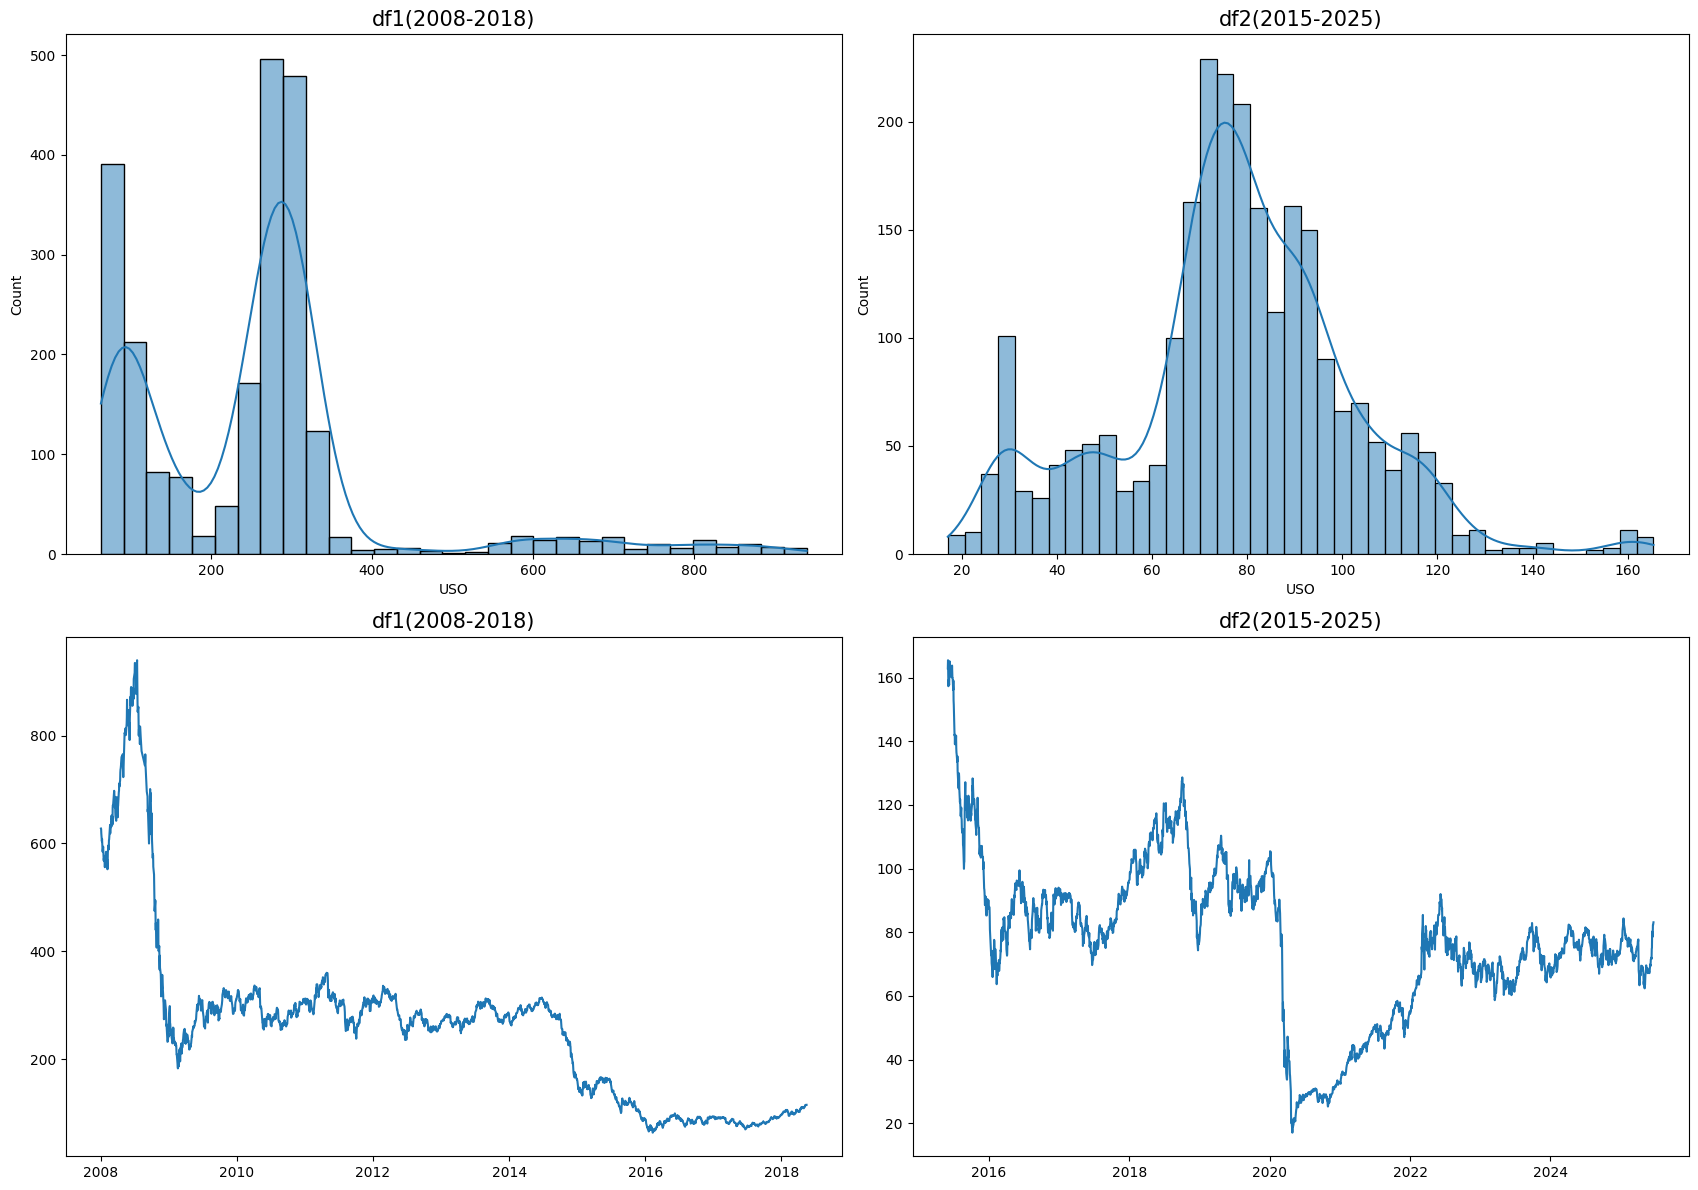


SUMMARY STATISTICS

df1 (2008-2018):
  Mean:   $254.74
  Median: $270.96
  Std:    $156.19
  Min:    $63.68
  Max:    $939.84
  Range:  $876.16

df2 (2015-2025):
  Mean:   $77.60
  Median: $77.76
  Std:    $24.56
  Min:    $17.04
  Max:    $165.44
  Range:  $148.40


In [19]:
plt.figure(figsize=(25,12))

plt.subplot(2,3,2)
sns.histplot(df1['USO'],kde=True)
plt.title("df1(2008-2018)",fontsize=15)


plt.subplot(2,3,3)
sns.histplot(df2['USO'],kde=True)
plt.title("df2(2015-2025)",fontsize=15)


plt.subplot(2,3,5)
plt.plot(df1['Date'],df1.USO, label=df1.USO)
plt.title("df1(2008-2018)",fontsize=15)

plt.subplot(2,3,6)
plt.plot(df2['Date'],df2.USO, label=df2.USO)
plt.title("df2(2015-2025)",fontsize=15)

plt.tight_layout()
plt.show()


print("\n" + "="*60)
datasets = [
    (df1, 'df1 (2008-2018)'),
    (df2, 'df2 (2015-2025)')
]
print("SUMMARY STATISTICS")
print("="*60)
for df, title in datasets:
    print(f"\n{title}:")
    print(f"  Mean:   ${df['USO'].mean():.2f}")
    print(f"  Median: ${df['USO'].median():.2f}")
    print(f"  Std:    ${df['USO'].std():.2f}")
    print(f"  Min:    ${df['USO'].min():.2f}")
    print(f"  Max:    ${df['USO'].max():.2f}")
    print(f"  Range:  ${df['USO'].max() - df['USO'].min():.2f}")

In [20]:
combined_df = pd.concat([df1, df2]).drop_duplicates(subset='Date', keep='first')

In [21]:
combined_df=combined_df.dropna()

In [22]:
combined_df.isnull().sum()

Date       0
SPX        0
GLD        0
USO        0
SLV        0
EUR/USD    0
dtype: int64

In [23]:
correlation = combined_df.corr(numeric_only=True)

In [24]:
combined_df['USO']=combined_df['USO'].round(2)

In [25]:
combined_df.duplicated(subset=['Date'], keep=False).sum()

0

In [26]:
combined_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4162 entries, 0 to 2526
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     4162 non-null   datetime64[ns]
 1   SPX      4162 non-null   float64       
 2   GLD      4162 non-null   float64       
 3   USO      4162 non-null   float64       
 4   SLV      4162 non-null   float64       
 5   EUR/USD  4162 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 227.6 KB


### Data Visualization

*Correlation:*
1. Positive Correlation
2. Negative Correlation

In [27]:
correlation=combined_df.corr()

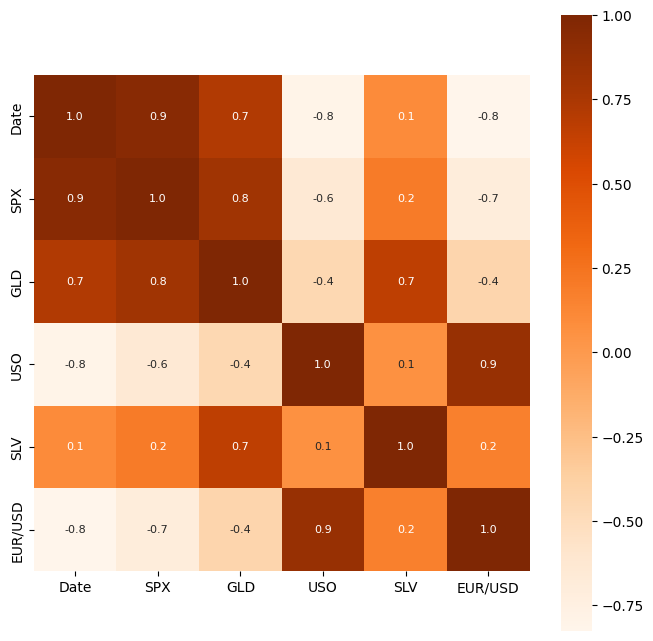

In [28]:
#constructing heatmap to understand correlation
plt.figure(figsize=(8,8))
sns.heatmap(correlation,cbar=True, square=True,fmt='.1f',annot=True,annot_kws={'size':8},cmap='Oranges')
plt.show()

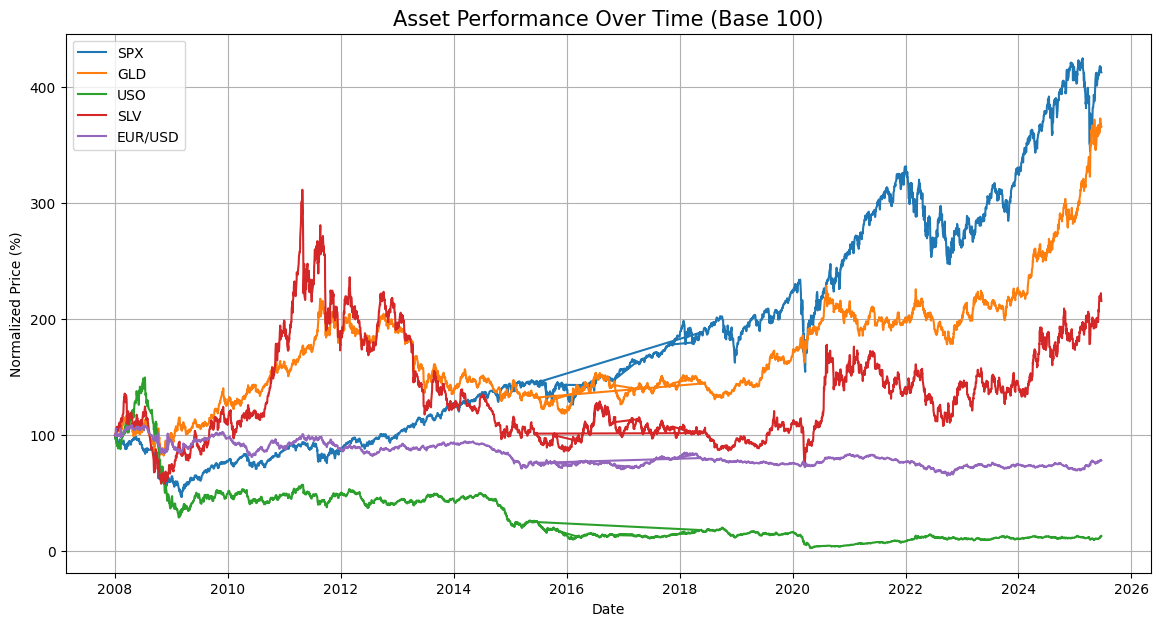

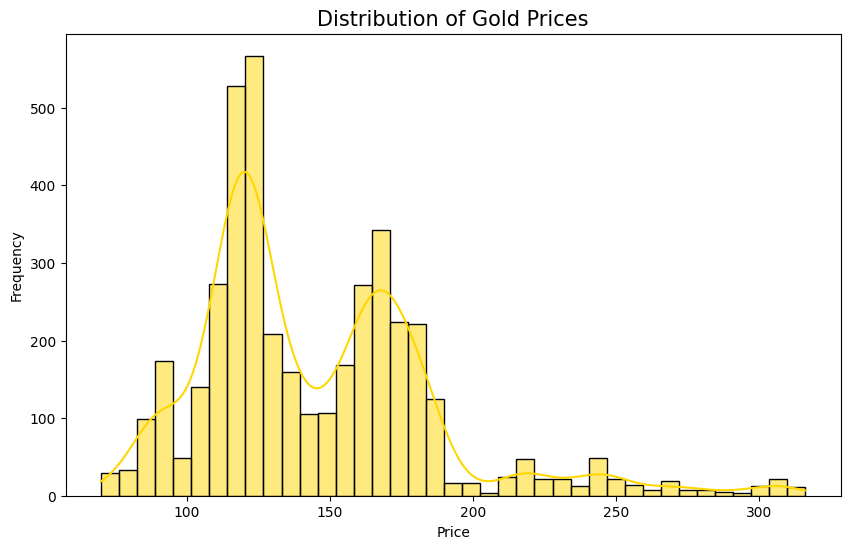

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# 1. Time Series Plot (Normalized to Base 100 for comparison)
plt.figure(figsize=(14, 7))
cols_to_plot = ['SPX', 'GLD', 'USO', 'SLV', 'EUR/USD']
for col in cols_to_plot:
    # Normalize by the first value to show percentage change
    plt.plot(combined_df['Date'], (combined_df[col] / combined_df[col].iloc[0]) * 100, label=col)

plt.title('Asset Performance Over Time (Base 100)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.grid(True)
plt.show()


# 3. Distribution of Gold (GLD) Prices
plt.figure(figsize=(10, 6))
sns.histplot(combined_df['GLD'], kde=True, color='gold')
plt.title('Distribution of Gold Prices', fontsize=15)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

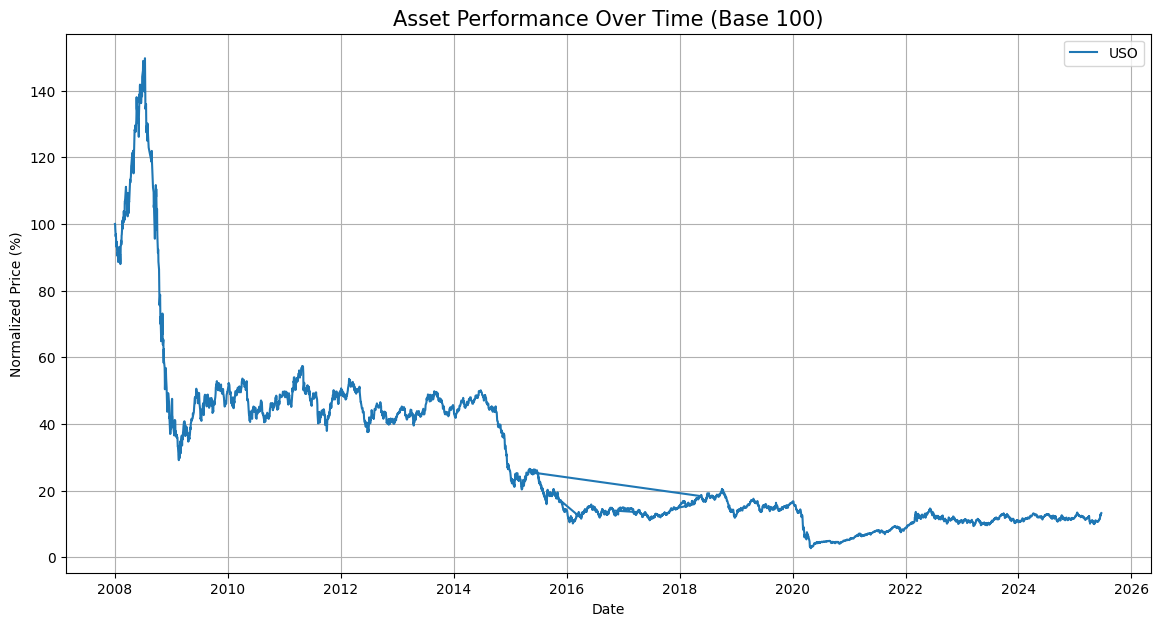

In [30]:
# 1. Time Series Plot (Normalized to Base 100 for comparison)
plt.figure(figsize=(14, 7))
cols_to_plot = ['USO']
for col in cols_to_plot:
    # Normalize by the first value to show percentage change
    plt.plot(combined_df['Date'], (combined_df[col] / combined_df[col].iloc[0]) * 100, label=col)

plt.title('Asset Performance Over Time (Base 100)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.grid(True)
plt.show()


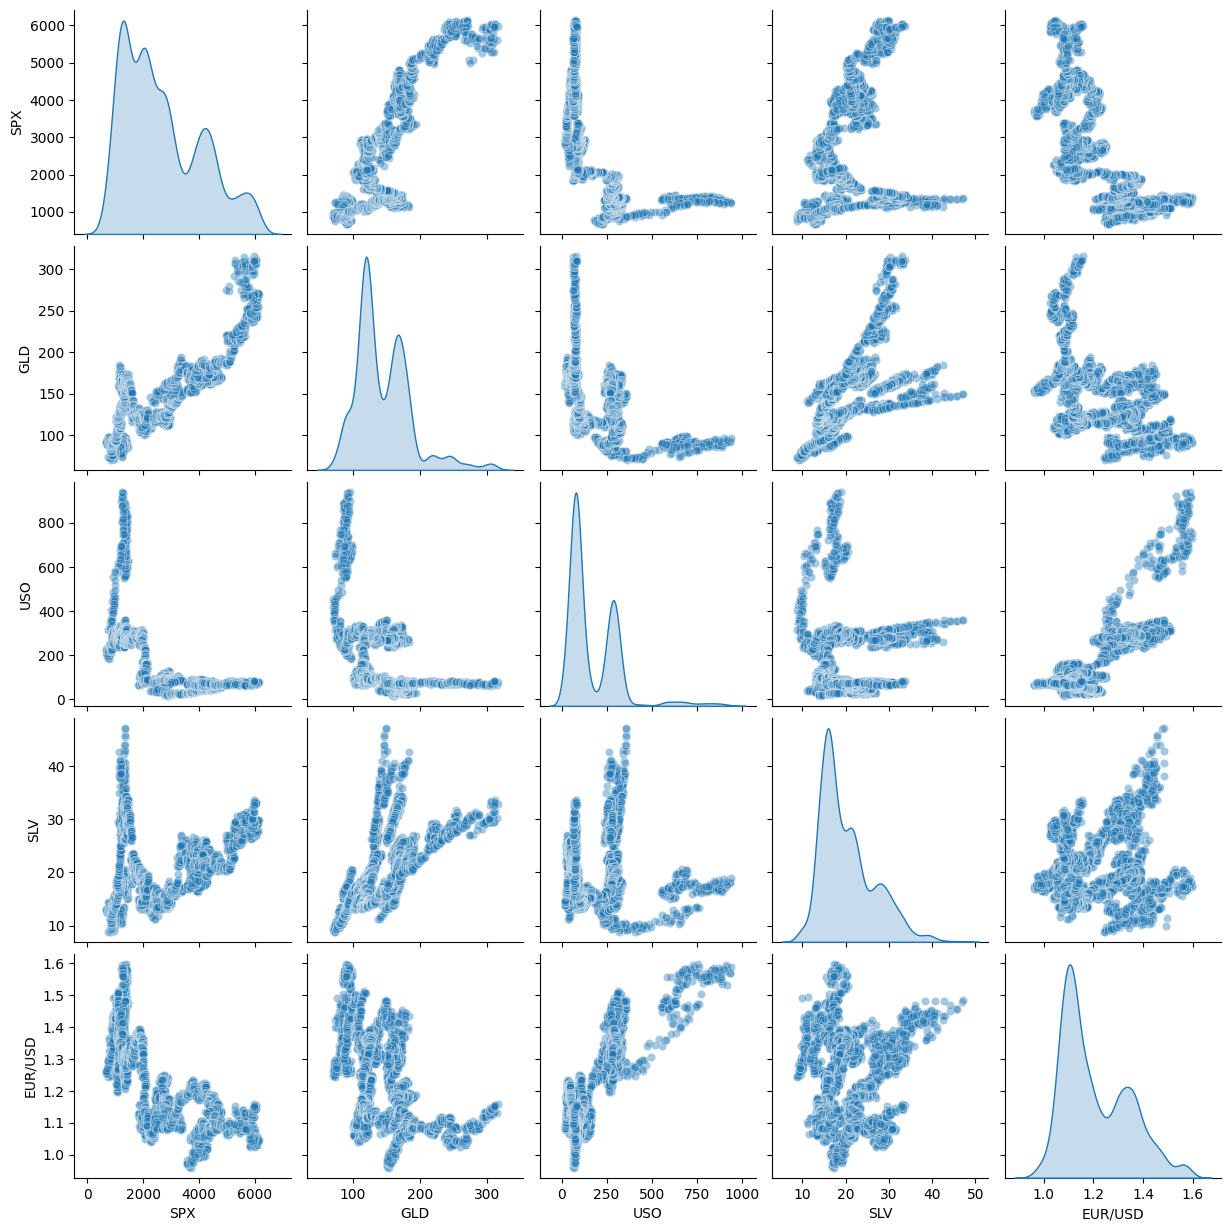

In [31]:
sns.pairplot(combined_df.drop(columns=['Date']), diag_kind='kde', plot_kws={'alpha': 0.4})
plt.show()

In [32]:
#correlation values of GLD
print(correlation['GLD'])

Date       0.720412
SPX        0.800851
GLD        1.000000
USO       -0.448065
SLV        0.658161
EUR/USD   -0.424676
Name: GLD, dtype: float64


C:\Users\tanma\AppData\Local\Temp\ipykernel_33240\230547961.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(combined_df['GLD'])


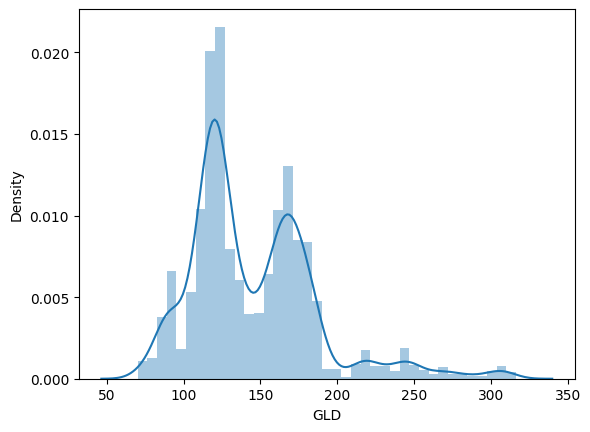

In [33]:
#cheacking the distribution of GLD values
sns.distplot(combined_df['GLD'])
plt.show()

### Data Splitting

In [34]:
X=combined_df.drop(['Date','GLD'],axis=1)
y=combined_df['GLD']

In [35]:
#Splittiing into Treining and testing data
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

### Model Selection

In [36]:
rf=RandomForestRegressor()
rf.fit(X_train,y_train)


RandomForestRegressor()

In [37]:
import joblib
joblib.dump(rf,"RandomeForest.joblib")

['RandomeForest.joblib']

### Model Evaluation

In [38]:
predict=rf.predict(X_test)

In [39]:
#R square error
error_score = metrics.r2_score(y_test, predict)

In [40]:
error_score

0.9953858127570014

In [41]:
combined_df.to_csv('combined_df.csv')

In [42]:
from sklearn.linear_model import LinearRegression

In [43]:
lr=LinearRegression()

In [44]:
lr.fit(X_train,y_train)

LinearRegression()

In [45]:
lr_predict=lr.predict(X_test)

In [46]:
lr_error_score = metrics.r2_score(y_test, lr_predict)

In [47]:
lr_error_score

0.8964630492992773

In [48]:
lr.predict([[1420.329956,592.16,16.061001,1.4801]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([98.3633366])

In [49]:
	
1420.329956,88.25,592.16,16.061001,1.4801

(1420.329956, 88.25, 592.16, 16.061001, 1.4801)

In [50]:
from sklearn.tree import DecisionTreeRegressor
dr=DecisionTreeRegressor()

In [51]:
dr.fit(X_train,y_train)

DecisionTreeRegressor()

In [52]:
dr_predict=dr.predict(X_test)

In [53]:
dr_error_score = metrics.r2_score(y_test, dr_predict)

In [54]:
dr_error_score

0.9891125737717767

In [55]:
from xgboost import XGBRegressor
xg=XGBRegressor()
xg.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [56]:
xg_predict=xg.predict(X_test)

In [57]:
xg_error_score=metrics.r2_score(y_test, xg_predict)

In [58]:
xg_error_score

0.9943439956037031

In [59]:
xg.predict([[1416.25,594.0,16.280001,1.4869]])

array([88.86309], dtype=float32)

In [60]:
dr.predict([[1416.25,594.0,16.280001,1.4869]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but DecisionTreeRegressor was fitted with feature names
  warnings.warn(


array([89.540001])

In [61]:
lr.predict([[1416.25,594.0,16.280001,1.4869]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([98.95592189])

In [62]:
rf.predict([[1416.25,594.0,16.280001,1.4869]])

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


array([89.68950071])

C:\Users\tanma\AppData\Local\Temp\ipykernel_33240\362754561.py:16: MatplotlibDeprecationWarning: Passing label as a length 4162 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(combined_df['Date'],combined_df.USO, label=combined_df.USO)
C:\Users\tanma\AppData\Local\Temp\ipykernel_33240\362754561.py:20: MatplotlibDeprecationWarning: Passing label as a length 2290 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(df1['Date'],df1.USO, label=df1.USO)
C:\Users\tanma\AppData\Local\Temp\ipykernel_33240\362754561.py:24: MatplotlibDeprecationWarning: Passing label as a length 2526 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string b

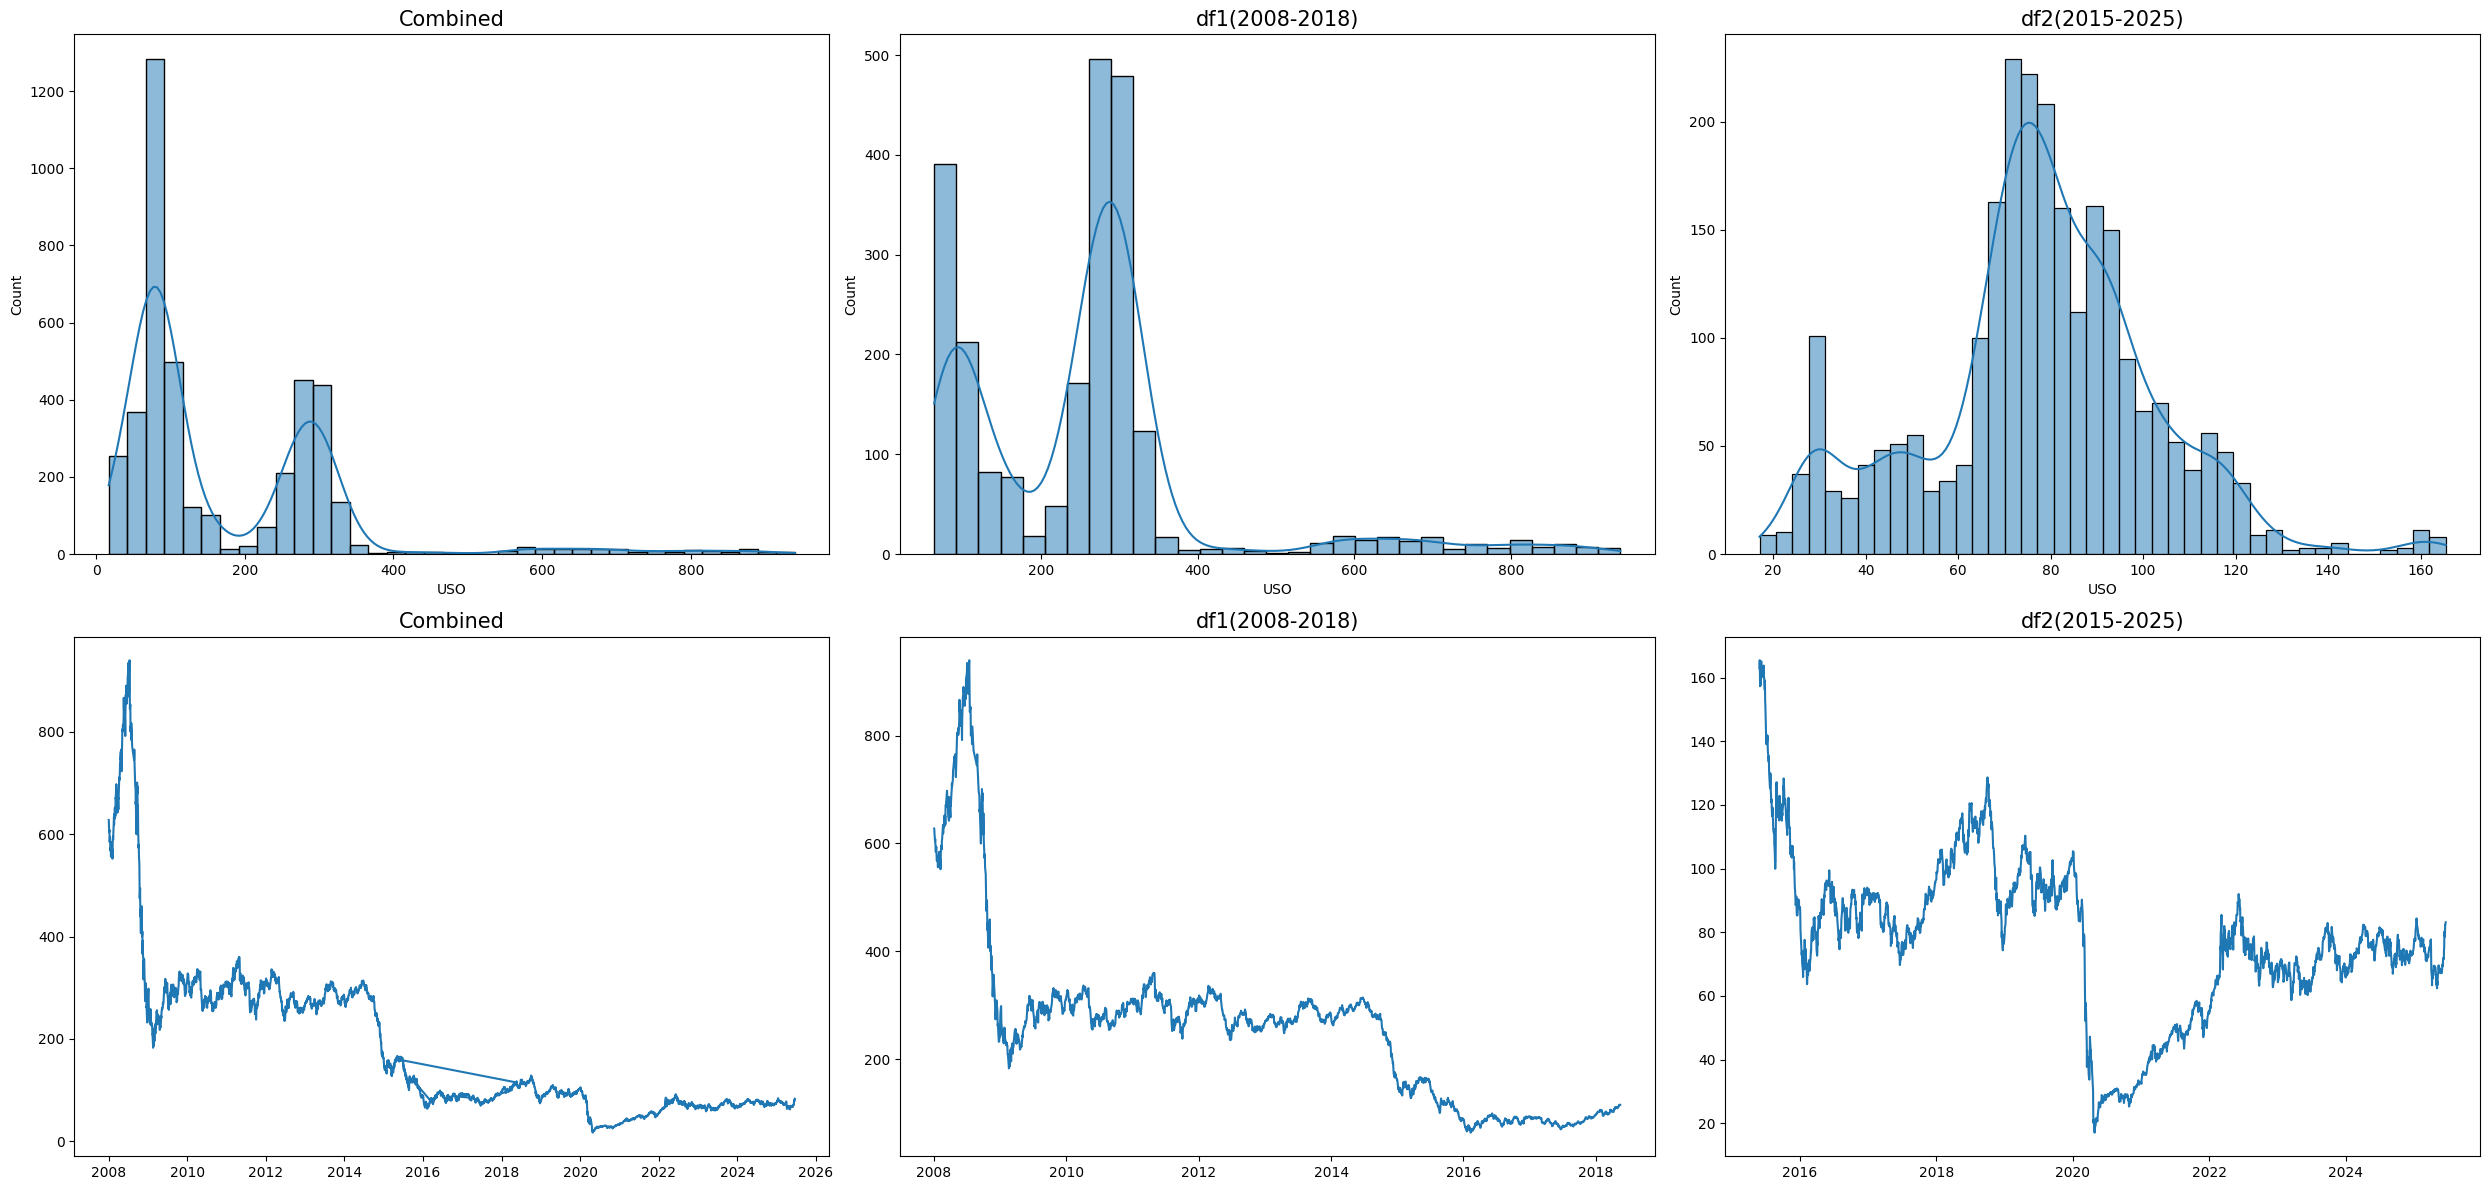


SUMMARY STATISTICS

Combined Dataset:
  Mean:   $172.51
  Median: $97.32
  Std:    $148.15
  Min:    $17.04
  Max:    $939.84
  Range:  $922.80

df1 (2008-2018):
  Mean:   $254.74
  Median: $270.96
  Std:    $156.19
  Min:    $63.68
  Max:    $939.84
  Range:  $876.16

df2 (2015-2025):
  Mean:   $77.60
  Median: $77.76
  Std:    $24.56
  Min:    $17.04
  Max:    $165.44
  Range:  $148.40


In [63]:
plt.figure(figsize=(25,12))
plt.subplot(2,3,1)
sns.histplot(combined_df['USO'],kde=True)
plt.title("Combined",fontsize=15)

plt.subplot(2,3,2)
sns.histplot(df1['USO'],kde=True)
plt.title("df1(2008-2018)",fontsize=15)


plt.subplot(2,3,3)
sns.histplot(df2['USO'],kde=True)
plt.title("df2(2015-2025)",fontsize=15)

plt.subplot(2,3,4)
plt.plot(combined_df['Date'],combined_df.USO, label=combined_df.USO)
plt.title("Combined",fontsize=15)

plt.subplot(2,3,5)
plt.plot(df1['Date'],df1.USO, label=df1.USO)
plt.title("df1(2008-2018)",fontsize=15)

plt.subplot(2,3,6)
plt.plot(df2['Date'],df2.USO, label=df2.USO)
plt.title("df2(2015-2025)",fontsize=15)

plt.tight_layout()
plt.show()


print("\n" + "="*60)
datasets = [
    (combined_df, 'Combined Dataset'),
    (df1, 'df1 (2008-2018)'),
    (df2, 'df2 (2015-2025)')
]
print("SUMMARY STATISTICS")
print("="*60)
for df, title in datasets:
    print(f"\n{title}:")
    print(f"  Mean:   ${df['USO'].mean():.2f}")
    print(f"  Median: ${df['USO'].median():.2f}")
    print(f"  Std:    ${df['USO'].std():.2f}")
    print(f"  Min:    ${df['USO'].min():.2f}")
    print(f"  Max:    ${df['USO'].max():.2f}")
    print(f"  Range:  ${df['USO'].max() - df['USO'].min():.2f}")

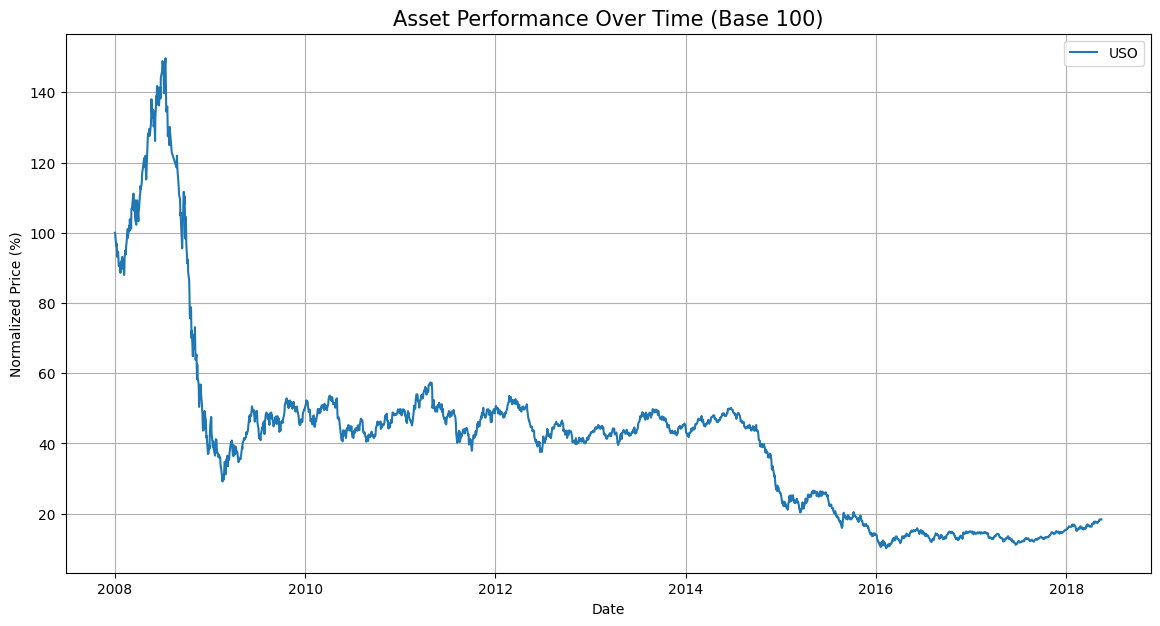

In [64]:
plt.figure(figsize=(14, 7))
cols_to_plot = ['USO']
for col in cols_to_plot:
    # Normalize by the first value to show percentage change
    plt.plot(df1['Date'], (df1[col] / df1[col].iloc[0]) * 100, label=col)

plt.title('Asset Performance Over Time (Base 100)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.grid(True)
plt.show()

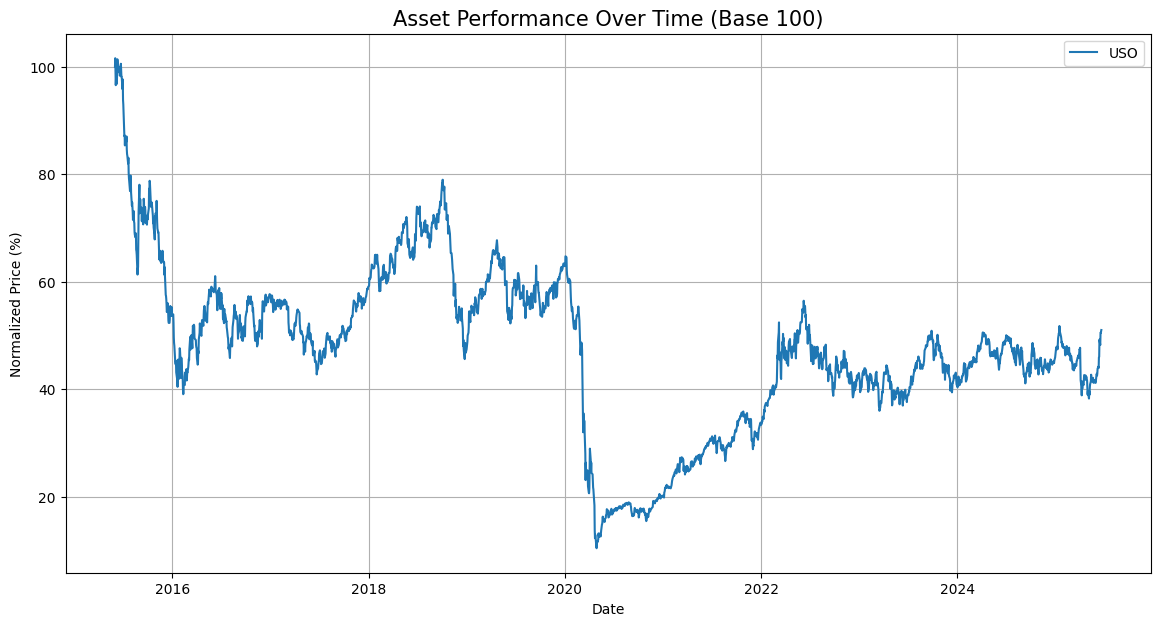

In [65]:
plt.figure(figsize=(14, 7))
cols_to_plot = ['USO']
for col in cols_to_plot:
    # Normalize by the first value to show percentage change
    plt.plot(df2['Date'], (df2[col] / df2[col].iloc[0]) * 100, label=col)

plt.title('Asset Performance Over Time (Base 100)', fontsize=15)
plt.xlabel('Date')
plt.ylabel('Normalized Price (%)')
plt.legend()
plt.grid(True)
plt.show()

In [66]:
df2

,Date,SPX,GLD,USO,SLV,EUR/USD
1,2015-06-01,2111.729980,114.000000,162.880005,16.000000,1.095794
2,2015-06-02,2109.600098,114.459999,165.440002,16.070000,1.092299
3,2015-06-03,2114.070068,113.639999,161.360001,15.830000,1.115001
4,2015-06-04,2095.840088,112.839996,157.279999,15.480000,1.125784
5,2015-06-05,2092.830078,112.239998,159.199997,15.390000,1.120787
...,...,...,...,...,...,...
2522,2025-06-13,5976.970215,316.290009,80.220001,32.970001,1.160025
2523,2025-06-16,6033.109863,311.779999,78.589996,33.029999,1.155668
2524,2025-06-17,5982.720215,311.940002,82.300003,33.740002,1.155135
2525,2025-06-18,5980.870117,310.260010,82.269997,33.270000,1.148264


C:\Users\tanma\AppData\Local\Temp\ipykernel_33240\237765683.py:2: MatplotlibDeprecationWarning: Passing label as a length 4162 sequence when plotting a single dataset is deprecated in Matplotlib 3.9 and will error in 3.11.  To keep the current behavior, cast the sequence to string before passing.
  plt.plot(combined_df['Date'],combined_df.USO, label=combined_df.USO)


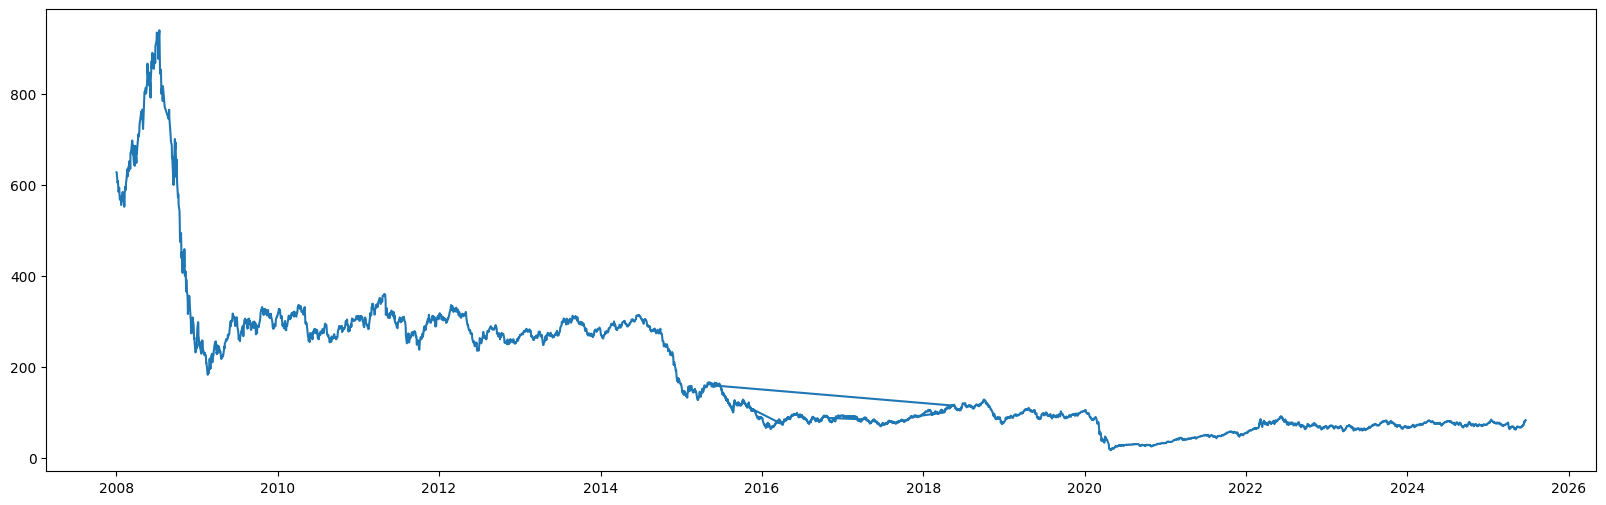

In [67]:
plt.figure(figsize=(20, 6))
plt.plot(combined_df['Date'],combined_df.USO, label=combined_df.USO)